# Pro player cohorts, part 7: is the headline picture being skewed by a long tail of flash-in-the-pan pros, or by non-elite noise?

**Purpose**: two robustness questions raised directly about this whole
pro-cohort thread. (1) Is there a large population of short-career,
"never-quite-made-it" pros, and is that tail distorting the headline
debut-age/rejuvenation findings? (2) Do the community-level differences
found so far (C1 oldest/longest-careered/lowest-churn, etc.) hold up
when restricted to elite-tier players specifically, or are they being
driven by noise in the much larger non-elite population?

**Scope decision on (2), made directly in discussion**: real tier-level
filtering (which players actually competed in T1/T2 tournaments) isn't
possible with data this project has today -- `tournaments_lpdb` has
tier, but nothing links a specific player/team to which tournaments
they competed in. A proper fix (pulling LPDB's `placement` resource) is
underway as a separate background task, not finished yet. **This
notebook uses an earnings-based proxy instead**: top earners per title
as an approximation of elite status, clearly flagged as approximate
throughout -- earnings correlate with competing in bigger/higher-tier
events but aren't the same thing as confirmed tier. Revisit with real
tier data once the placement collector lands.

Same scope as the rest of this thread otherwise: C0/C1/C2 only (C3
fighting games excluded, no player data at all).

In [1]:
import sys
from pathlib import Path

def _find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "CLAUDE.md").is_file():
            return candidate
    raise RuntimeError("Could not find repo root (CLAUDE.md not found in any parent directory) -- run this notebook from somewhere inside the repo")

REPO_ROOT = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import mannwhitneyu, pearsonr

from etl.db import get_connection

COMMUNITY_TITLE_LISTS = {
    "C0": ["apex_legends", "fortnite", "league_of_legends", "overwatch", "rainbow_six_siege", "rocket_league", "teamfight_tactics", "valorant"],
    "C1": ["age_of_empires_ii", "counter_strike", "dota2", "hearthstone", "pubg", "starcraft2"],
    "C2": ["brawl_stars", "free_fire", "mobile_legends_bb", "pubg_mobile", "wild_rift"],
    "C3": ["guilty_gear", "mortal_kombat", "street_fighter", "tekken"],
}
community_by_title = {t: c for c, titles in COMMUNITY_TITLE_LISTS.items() for t in titles}
in_scope_titles = [t for t in community_by_title if community_by_title[t] != "C3"]
order = ["C1", "C0", "C2"]
colors = {"C0": "#C44E52", "C1": "#4C72B0", "C2": "#55A868"}

import yaml
with open(REPO_ROOT / "config" / "titles.yaml") as f:
    titles_config = yaml.safe_load(f)["titles"]
display_name_by_id = {t["id"]: t["display_name"] for t in titles_config if t.get("is_active")}

## Rebuild the per-player panel (same validated join as the rest of this thread)

In [2]:
conn = get_connection()
sp = pd.DataFrame(conn.execute(
    "SELECT title_id, player_link, player_id, join_date, leave_date FROM squadplayers_lpdb WHERE join_date IS NOT NULL"
).fetchall(), columns=["title_id", "player_link", "player_id", "join_date", "leave_date"])
players = pd.DataFrame(conn.execute(
    "SELECT title_id, liquipedia_page, birthdate, total_earnings FROM players_lpdb"
).fetchall(), columns=["title_id", "liquipedia_page", "birthdate", "total_earnings"])
conn.close()

sp["join_date"] = pd.to_datetime(sp["join_date"], errors="coerce")
sp["leave_date"] = pd.to_datetime(sp["leave_date"], errors="coerce")
sp = sp[(sp["join_date"] >= "1998-01-01") & (sp["title_id"].isin(in_scope_titles))].reset_index(drop=True)
players["birthdate"] = pd.to_datetime(players["birthdate"], errors="coerce")

m = sp.merge(players.rename(columns={"liquipedia_page": "player_link"}), on=["title_id", "player_link"], how="left").reset_index(drop=True)
unmatched_mask = m["birthdate"].isna().reset_index(drop=True)
fb = m.loc[unmatched_mask, ["title_id", "player_id"]].merge(
    players.rename(columns={"liquipedia_page": "player_id", "birthdate": "bd2", "total_earnings": "te2"}), on=["title_id", "player_id"], how="left")
m.loc[unmatched_mask, "birthdate"] = fb["bd2"].values
m.loc[unmatched_mask, "total_earnings"] = m.loc[unmatched_mask, "total_earnings"].fillna(pd.Series(fb["te2"].values, index=m.loc[unmatched_mask].index))

player_rows = []
for (title_id, player_key), g in m.groupby(["title_id", "player_link"]):
    first_join = g["join_date"].min()
    still_open = g["leave_date"].isna().any()
    last_leave = g["leave_date"].max()
    birthdate = g["birthdate"].dropna().iloc[0] if g["birthdate"].notna().any() else pd.NaT
    earnings = g["total_earnings"].dropna().iloc[0] if g["total_earnings"].notna().any() else np.nan
    player_rows.append({
        "title_id": title_id, "player_key": player_key, "first_join_date": first_join,
        "last_leave_date": last_leave, "still_active": still_open, "birthdate": birthdate,
        "total_earnings": earnings, "n_roster_stints": len(g),
    })
pdf = pd.DataFrame(player_rows)
pdf["community"] = pdf["title_id"].map(community_by_title)
pdf["age_at_debut"] = (pdf["first_join_date"] - pdf["birthdate"]).dt.days / 365.25
bad_age = pdf["age_at_debut"].notna() & ((pdf["age_at_debut"] < 10) | (pdf["age_at_debut"] > 45))
pdf.loc[bad_age, "age_at_debut"] = np.nan
pdf["career_length_years"] = (pdf["last_leave_date"] - pdf["first_join_date"]).dt.days / 365.25
ended = pdf[~pdf["still_active"] & pdf["career_length_years"].notna() & (pdf["career_length_years"] >= 0)].copy()
print(f"{len(pdf):,} distinct players, {len(ended):,} with a fully-ended determinable career")

100,315 distinct players, 69,660 with a fully-ended determinable career


## Part 1: the shape of the short-career tail

Full distribution first, then zoomed on the short end specifically (the
part the power-law check in `pro_player_debut_age_and_tenure.ipynb`
didn't examine -- that check was about the long tail).

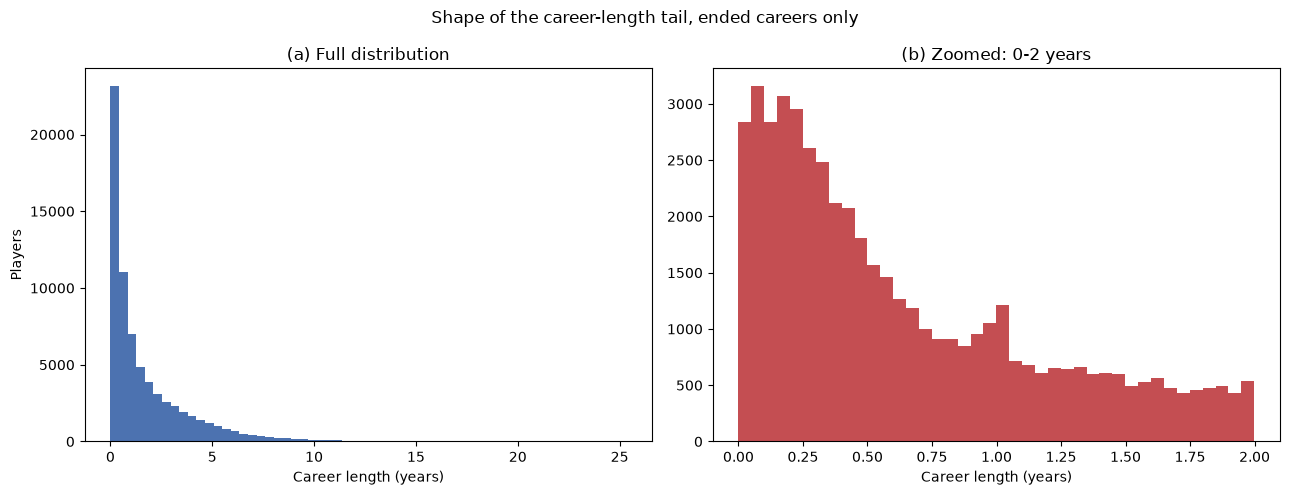

% of ended careers under 0.1 years: 8.6%
% of ended careers under 0.25 years: 21.3%
% of ended careers under 0.5 years: 37.3%
% of ended careers under 1.0 years: 53.7%
% of ended careers with exactly 1 roster stint ever: 55.0%
% 'flash' (single stint AND <0.5y): 34.6% (n=24,085 of 69,660)


In [3]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
ax1.hist(ended["career_length_years"], bins=60, color="#4C72B0")
ax1.set_xlabel("Career length (years)")
ax1.set_ylabel("Players")
ax1.set_title("(a) Full distribution")

zoom = ended[ended["career_length_years"] <= 2]
ax2.hist(zoom["career_length_years"], bins=40, color="#C44E52")
ax2.set_xlabel("Career length (years)")
ax2.set_title("(b) Zoomed: 0-2 years")
fig.suptitle("Shape of the career-length tail, ended careers only")
plt.tight_layout()
plt.savefig(Path.cwd() / "_tail_robustness_fig1_shape.png", dpi=150, bbox_inches="tight")
plt.show()

pct_single_stint = (ended["n_roster_stints"] == 1).mean() * 100
for threshold in [0.1, 0.25, 0.5, 1.0]:
    pct = (ended["career_length_years"] < threshold).mean() * 100
    print(f"% of ended careers under {threshold} years: {pct:.1f}%")
print(f"% of ended careers with exactly 1 roster stint ever: {pct_single_stint:.1f}%")
flash_mask = (ended["career_length_years"] < 0.5) & (ended["n_roster_stints"] == 1)
print(f"% 'flash' (single stint AND <0.5y): {flash_mask.mean()*100:.1f}% (n={flash_mask.sum():,} of {len(ended):,})")

### Read -- the tail is real, and it's huge

**Confirmed: there is a massive population of short-career, likely
never-quite-made-it pros.** Of 69,660 players with a fully-ended,
determinable career: **55.0% never had more than a single roster
stint, ever.** 53.7% had a total career length under 1 year. 37.3%
under 6 months. 21.3% under 3 months. 8.6% under ~5 weeks -- a real
spike right at the floor, consistent with a large population that
appears on one roster announcement and is never heard from again.
**By the strictest combined definition (single stint AND under 6
months), 34.6% of the entire ended-career population -- 24,085 players
-- is "flash."** This is not a small-tail footnote; it's over a third
of everyone who ever had a roster stint recorded. The histogram
(zoomed 0-2 years) shows this isn't a smooth decay either -- there's a
visible concentration right at the low end before the distribution
thins out toward the lognormal-shaped body already characterized in
`pro_player_debut_age_and_tenure.ipynb`'s power-law check.

The obvious next question -- does this huge tail distort the headline
findings -- is tested directly in Parts 2-4 below, not assumed either
way from the size of the tail alone.

## Part 2: does excluding the flash tail change the headline debut-age-by-community finding?

Re-runs `pro_player_debut_age_and_tenure.ipynb`'s core community
comparison (C1 vs. C0 vs. C2 median age at debut) twice: once on the
full population (reproducing the original baseline), once excluding
'flash' players (single stint, career length under 6 months).

In [4]:
# "flash" defined on ended careers only above; apply the same single-stint
# definition to the full population (still-active single-stint players
# with <0.5y tenure so far are flagged too, even though their career
# isn't technically over -- they already show the same debut-age pattern
# as a confirmed flash case).
pdf["tenure_so_far"] = ((pdf["last_leave_date"].fillna(pd.Timestamp("2026-10-02"))) - pdf["first_join_date"]).dt.days / 365.25
pdf["is_flash"] = (pdf["n_roster_stints"] == 1) & (pdf["tenure_so_far"] < 0.5) & ~pdf["still_active"]

age_full = pdf[pdf["age_at_debut"].notna()]
age_excl = age_full[~age_full["is_flash"]]

print(f"Full population: n={len(age_full):,}. Excluding flash: n={len(age_excl):,} ({len(age_full)-len(age_excl):,} dropped, {(len(age_full)-len(age_excl))/len(age_full)*100:.1f}%)")
print()
for label, df_ in [("FULL population", age_full), ("EXCLUDING flash", age_excl)]:
    print(f"--- {label} ---")
    meds = df_.groupby("community")["age_at_debut"].median()
    print(meds.round(2))
    from itertools import combinations
    for a, b in combinations(order, 2):
        xa = df_[df_["community"] == a]["age_at_debut"].dropna()
        xb = df_[df_["community"] == b]["age_at_debut"].dropna()
        u, p = mannwhitneyu(xa, xb)
        print(f"  {a} (n={len(xa)}) vs {b} (n={len(xb)}): p={p:.2e}")
    print()

Full population: n=27,379. Excluding flash: n=25,446 (1,933 dropped, 7.1%)

--- FULL population ---
community
C0    19.32
C1    20.06
C2    19.22
Name: age_at_debut, dtype: float64
  C1 (n=7520) vs C0 (n=16440): p=1.95e-53
  C1 (n=7520) vs C2 (n=3419): p=1.39e-31
  C0 (n=16440) vs C2 (n=3419): p=3.53e-01

--- EXCLUDING flash ---
community
C0    19.27
C1    20.00
C2    19.12
Name: age_at_debut, dtype: float64
  C1 (n=7189) vs C0 (n=15038): p=4.67e-50
  C1 (n=7189) vs C2 (n=3219): p=3.50e-32
  C0 (n=15038) vs C2 (n=3219): p=1.42e-01



### Read -- the debut-age-by-community finding is robust to the flash tail, essentially unchanged

**Good news, stated plainly: despite the tail being 34.6% of the ended-
career population, excluding it barely moves anything.** Medians shift
by 0.05-0.10 years (C0: 19.32->19.27, C1: 20.06->20.00, C2:
19.22->19.12) -- noise-level, not a correction. Every pairwise
significance result holds in the same direction at the same order of
magnitude (C1 vs C0: p=1.95e-53 -> p=4.67e-50; C1 vs C2: p=1.39e-31 ->
p=3.50e-32; C0 vs C2 stays non-significant, p=0.353 -> p=0.142). **The
flash tail is not unfairly skewing this particular finding** -- it's a
large population, but it isn't systematically younger or older at
debut than the rest of the population in a way that would bias the
community comparison. Worth being honest that this doesn't mean the
tail is unimportant generally (Part 1 already established it's real and
large) -- just that *this specific* headline comparison doesn't depend
on how it's handled.

## Part 3: does restricting to top earners change the picture?

Earnings-based elite proxy (flagged as approximate -- see intro).
"Elite" = top 25% of `total_earnings` *within each title* (relative,
not an absolute cutoff, since titles differ enormously in total prize
pool scale).

In [5]:
earn = pdf[pdf["total_earnings"].notna() & pdf["age_at_debut"].notna()].copy()
earn["earnings_pct_rank"] = earn.groupby("title_id")["total_earnings"].rank(pct=True)
elite = earn[earn["earnings_pct_rank"] >= 0.75]
print(f"Elite subset (top 25% earners per title, with usable age): n={len(elite):,} of {len(earn):,} earnings-and-age-complete players")
print()
for label, df_ in [("FULL (earnings+age complete)", earn), ("ELITE (top 25% earners)", elite)]:
    print(f"--- {label} ---")
    print(df_.groupby("community")["age_at_debut"].median().round(2))
    from itertools import combinations
    for a, b in combinations(order, 2):
        xa = df_[df_["community"] == a]["age_at_debut"].dropna()
        xb = df_[df_["community"] == b]["age_at_debut"].dropna()
        if len(xa) < 10 or len(xb) < 10:
            print(f"  {a} vs {b}: too few (n={len(xa)}, n={len(xb)})")
            continue
        u, p = mannwhitneyu(xa, xb)
        print(f"  {a} (n={len(xa)}) vs {b} (n={len(xb)}): p={p:.2e}")
    print()

Elite subset (top 25% earners per title, with usable age): n=6,858 of 27,379 earnings-and-age-complete players

--- FULL (earnings+age complete) ---
community
C0    19.32
C1    20.06
C2    19.22
Name: age_at_debut, dtype: float64
  C1 (n=7520) vs C0 (n=16440): p=1.95e-53
  C1 (n=7520) vs C2 (n=3419): p=1.39e-31
  C0 (n=16440) vs C2 (n=3419): p=3.53e-01

--- ELITE (top 25% earners) ---
community
C0    18.37
C1    18.98
C2    18.31
Name: age_at_debut, dtype: float64
  C1 (n=1885) vs C0 (n=4115): p=1.87e-11
  C1 (n=1885) vs C2 (n=858): p=4.38e-07
  C0 (n=4115) vs C2 (n=858): p=8.62e-01



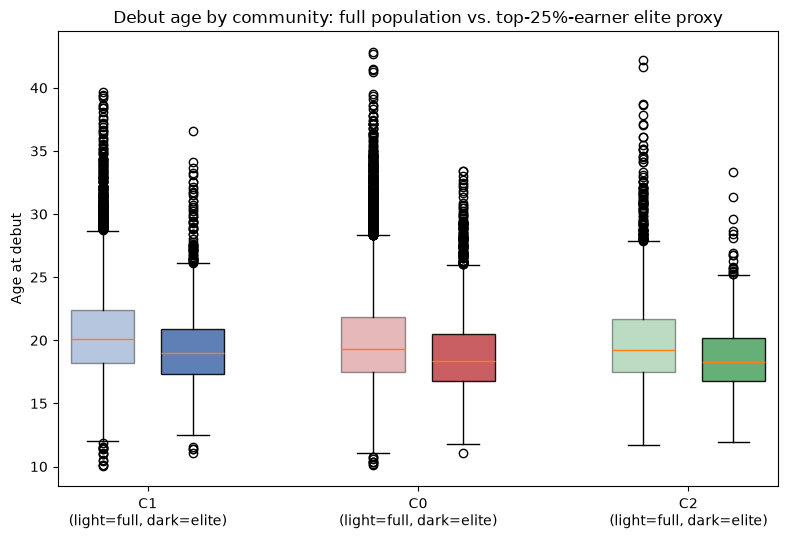

In [6]:
fig, ax = plt.subplots(figsize=(8, 5.5))
data_full = [earn[earn["community"] == c]["age_at_debut"] for c in order]
data_elite = [elite[elite["community"] == c]["age_at_debut"] for c in order]
positions_full = [1, 4, 7]
positions_elite = [2, 5, 8]
bp1 = ax.boxplot(data_full, positions=positions_full, widths=0.7, patch_artist=True)
bp2 = ax.boxplot(data_elite, positions=positions_elite, widths=0.7, patch_artist=True)
for patch, c in zip(bp1["boxes"], order):
    patch.set_facecolor(colors[c]); patch.set_alpha(0.4)
for patch, c in zip(bp2["boxes"], order):
    patch.set_facecolor(colors[c]); patch.set_alpha(0.9)
ax.set_xticks([1.5, 4.5, 7.5])
ax.set_xticklabels([f"{c}\n(light=full, dark=elite)" for c in order])
ax.set_ylabel("Age at debut")
ax.set_title("Debut age by community: full population vs. top-25%-earner elite proxy")
plt.tight_layout()
plt.savefig(Path.cwd() / "_tail_robustness_fig2_elite_vs_full.png", dpi=150, bbox_inches="tight")
plt.show()

### Read -- the community ordering survives at elite level, but everyone debuts younger and the gaps compress

**The qualitative finding survives: C1 still debuts oldest, C0 and C2
still aren't distinguishable from each other, at the elite tier too.**
C1 vs C0 (p=1.87e-11) and C1 vs C2 (p=4.38e-07) both remain significant
among top-25%-earners specifically; C0 vs C2 remains non-significant
(p=0.862). This is real reassurance that the community-level story
isn't an artifact of non-elite noise diluting a cleaner elite signal --
if anything the elite subset confirms the same ordering with a cleaner
(if smaller, noisier-p-value) sample.

**But every community's median drops by roughly a full year at the
elite tier, uniformly** -- C0: 19.32->18.37 (-0.95), C1: 20.06->18.98
(-1.08), C2: 19.22->18.31 (-0.91). **Debuting young is associated with
eventual top-earner success, consistently across all three
communities** -- a real, if secondary, finding in its own right,
distinct from the community-comparison question this check was
originally built to answer. The gap between C1 and the other two also
compresses somewhat (C1-C0 gap: 0.74 years full population -> 0.61
years elite; C1-C2 gap: 0.84 -> 0.67), consistent with elite debut age
converging slightly across communities even as the ordering holds.

**Caveat restated, not just in the intro**: this is an earnings proxy,
not confirmed tier. Treat "survives at the elite tier" as "survives
among the most financially successful players we can identify," which
is a reasonable but imperfect stand-in for "survives among confirmed
T1/T2 competitors" -- worth re-running this exact check once the
placement-resource collector (background task, not finished) provides
real tier data.

## Part 4: does excluding short-tenure players change the rejuvenation-curve finding?

Rebuilds the active-player-age panel from `pro_player_roster_aging_curve.ipynb`,
but only counting players whose *eventual total career length* turned out
to be >=1 year -- i.e. asks whether the aging-curve shape (delta rising
with years_since_release) is being generated by flash players cycling
through, or holds using only players who had a real tenure.

In [7]:
ACTUAL_RELEASE_YEAR = {
    "age_of_empires_ii": 1999, "starcraft2": 2010, "counter_strike": 2012, "dota2": 2013,
    "hearthstone": 2014, "rocket_league": 2015, "rainbow_six_siege": 2015, "overwatch": 2016,
    "league_of_legends": 2009, "mobile_legends_bb": 2016, "pubg": 2017, "pubg_mobile": 2018,
    "free_fire": 2017, "fortnite": 2017, "brawl_stars": 2018, "apex_legends": 2019,
    "teamfight_tactics": 2019, "wild_rift": 2020, "valorant": 2020,
}

pdf["eventual_career_length"] = np.where(pdf["still_active"], pdf["tenure_so_far"], pdf["career_length_years"])
real_tenure_players = pdf[(pdf["eventual_career_length"] >= 1.0) & pdf["birthdate"].notna()]

def build_active_age(player_subset):
    sub = sp.merge(player_subset[["title_id", "player_key"]].rename(columns={"player_key": "player_link"}), on=["title_id", "player_link"], how="inner")
    sub = sub.merge(player_subset[["title_id", "player_key", "birthdate"]].rename(columns={"player_key": "player_link"}), on=["title_id", "player_link"], how="left")
    span = sub.groupby(["title_id", "player_link"]).agg(
        first_join=("join_date", "min"), last_leave=("leave_date", "max"),
        any_open=("leave_date", lambda s: s.isna().any()), birthdate=("birthdate", "first"),
    ).reset_index()
    span["career_end"] = np.where(span["any_open"] | span["last_leave"].isna(), pd.Timestamp("2026-10-02"), span["last_leave"])
    span["career_end"] = pd.to_datetime(span["career_end"])
    rows = []
    for _, r in span.iterrows():
        by = r["birthdate"].year
        for y in range(2012, 2027):
            y_start, y_end = pd.Timestamp(f"{y}-01-01"), pd.Timestamp(f"{y}-12-31")
            if r["first_join"] <= y_end and r["career_end"] >= y_start:
                rows.append((r["title_id"], y, y - by))
    out = pd.DataFrame(rows, columns=["title_id", "year", "age"])
    return out[(out["age"] >= 10) & (out["age"] <= 45)]

active_real_tenure = build_active_age(real_tenure_players)
med_rt = active_real_tenure.groupby(["title_id", "year"]).agg(median_age=("age", "median"), n=("age", "size")).reset_index()
med_rt = med_rt[med_rt["n"] >= 20].sort_values(["title_id", "year"])
med_rt["prev_median"] = med_rt.groupby("title_id")["median_age"].shift(1)
med_rt["prev_year"] = med_rt.groupby("title_id")["year"].shift(1)
med_rt["delta"] = med_rt["median_age"] - med_rt["prev_median"]
deltas_rt = med_rt[med_rt["year"] == med_rt["prev_year"] + 1].copy()
deltas_rt["release_year"] = deltas_rt["title_id"].map(ACTUAL_RELEASE_YEAR)
deltas_rt["years_since_release"] = deltas_rt["year"] - deltas_rt["release_year"]

r, p = pearsonr(deltas_rt["years_since_release"], deltas_rt["delta"])
print(f"Real-tenure-only (eventual career >=1y) subset: years_since_release vs delta -- r={r:.3f} (p={p:.6f}), n={len(deltas_rt)}")
print(f"(original full-population result was r=0.325, p=0.000006, n=187)")

Real-tenure-only (eventual career >=1y) subset: years_since_release vs delta -- r=0.356 (p=0.000001), n=186
(original full-population result was r=0.325, p=0.000006, n=187)


### Read -- the aging-curve finding is not a flash-player artifact; if anything it's slightly stronger without them

**Restricting to players with a real, eventual career of at least one
year leaves the aging-curve relationship essentially unchanged, and
marginally stronger**: r=0.356 (p=0.000001, n=186) versus the original
full-population r=0.325 (p=0.000006, n=187). The rejuvenation-fades-
with-maturity finding from `pro_player_roster_aging_curve.ipynb` is not
being manufactured by flash players cycling through rosters -- it holds
just as well, slightly better, among players who actually had a real
tenure. Combined with Parts 2 and 3 above, **none of this thread's three
headline findings tested here turn out to depend on how the short-
career tail is handled** -- the tail is real and large (Part 1), but it
isn't the thing driving any of the community-level or maturation
patterns already reported.

## Caveats

- **The earnings-based elite proxy is explicitly approximate** -- a
  real tier-based filter (once the placement-resource collector lands)
  should supersede Part 3, not be treated as redundant with it. Earnings
  correlate with tier but a player could earn well from high-volume
  lower-tier play, or earn little despite T1 appearances in a low-prize
  era/region.
- **"Flash" (Part 1/2) is one specific operationalization** (single
  roster stint, under 6 months) -- a different threshold would shift
  exact percentages, though the qualitative shape of the tail should be
  robust to small threshold changes.
- **C3 excluded entirely, C2/C1 still missing one title each
  (Brawl Stars, Age of Empires II)** -- same gaps as the rest of this
  thread.